<a href="https://colab.research.google.com/github/vivekkumarbehera/Machine_learning_Pratical_Implement/blob/main/Predict_Fuel_Efficiency.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import tensorflow as tf
import tensorflow as keras
from tensorflow.keras import layers

In [12]:
column_names = ['MPG','Cylinders','Displacement','Horsepower','Weight',
                'Acceleration', 'Model Year', 'Origin']
dataset = pd.read_csv("auto-mpg.csv", names=column_names,
                      na_values = "?", comment='\t',
                      sep=",", skipinitialspace=True, header=None)

In [13]:
'''
The “origin” column in the dataset is categorical, so to move forward we need to use some one-hot encoding on it:
'''
origin = dataset.pop('Origin')
dataset['USA'] = (origin == 1)*1.0
dataset['Europe'] = (origin == 2)*1.0
dataset['Japan'] = (origin == 3)*1.0

In [14]:
#Now, let’s split the data into training and test sets:
train_dataset = dataset.sample(frac=0.8,random_state=0)
test_dataset = dataset.drop(train_dataset.index)

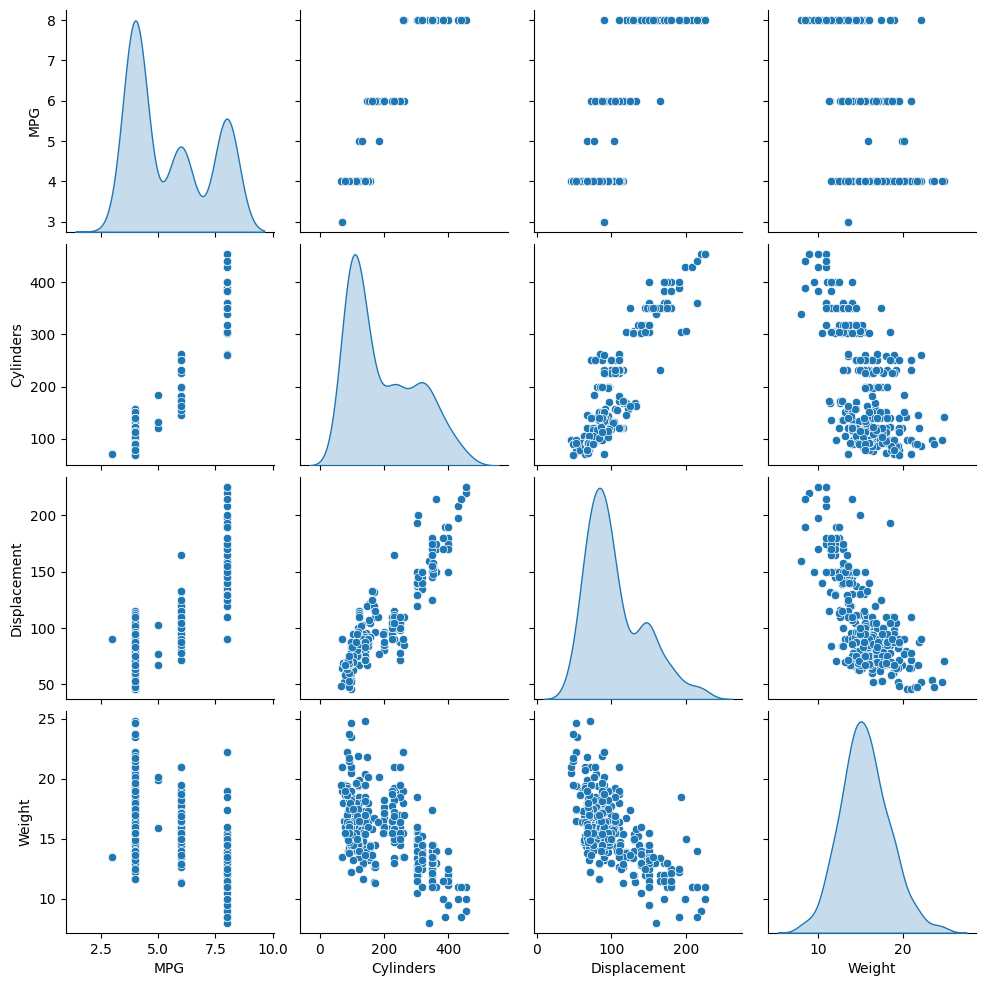

In [16]:
#Before training and test to predict fuel efficiency with machine learning, let’s visualize the data by using the seaborn’s pair plot method:

# The error 'ValueError: No variables found for grid columns.' typically occurs when
# seaborn.pairplot cannot find numeric columns to plot. This often happens if the
# columns intended for plotting are not of a numeric data type (e.g., they are 'object'
# dtype due to strings or mixed types), even if they appear numeric in a preview.

# To fix this, we will ensure that the selected columns are explicitly converted to numeric
# types. 'errors=\'coerce\'' will turn any non-numeric values into NaN, which can then be
# optionally dropped.

plot_columns = ["MPG", "Cylinders", "Displacement", "Weight"]
df_to_plot = train_dataset[plot_columns].copy()

for col in plot_columns:
    df_to_plot[col] = pd.to_numeric(df_to_plot[col], errors='coerce')

# Drop rows with NaN values in the plotting columns to ensure clean data for KDE.
df_to_plot.dropna(inplace=True)

sns.pairplot(df_to_plot, diag_kind="kde")

In [19]:
#Normalize the Data

# Ensure all columns intended for numerical processing are actually numeric.
# This addresses potential issues from previous data loading steps where columns
# like 'MPG' might have been read as 'object' type.
numeric_feature_cols = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight', 'Acceleration', 'Model Year']

for col in numeric_feature_cols:
    train_dataset[col] = pd.to_numeric(train_dataset[col], errors='coerce')
    test_dataset[col] = pd.to_numeric(test_dataset[col], errors='coerce')

# Drop any rows where 'MPG' or other critical numeric columns became NaN during conversion.
# This ensures a clean dataset for normalization and model training.
train_dataset.dropna(subset=numeric_feature_cols, inplace=True)
test_dataset.dropna(subset=numeric_feature_cols, inplace=True)


# Separate the target variable ('MPG') from the features for both datasets.
# 'MPG' will become our labels for model training.
train_labels = train_dataset.pop('MPG')
test_labels = test_dataset.pop('MPG')


# Calculate statistics for normalization exclusively on the training features.
# This prevents data leakage from the test set and ensures consistent scaling.
train_stats = train_dataset.describe().transpose()

# Define the normalization function using the calculated training statistics.
def norm(x):
  return (x - train_stats['mean']) / train_stats['std']

# Apply normalization to both the training and test features.
normed_train_data = norm(train_dataset)
normed_test_data = norm(test_dataset)

In [22]:
#Build The Model
def build_model():
  model = tf.keras.Sequential([
    tf.keras.Input(shape=[len(train_dataset.keys())]),
    layers.Dense(64, activation=tf.nn.relu),
    layers.Dense(64, activation=tf.nn.relu),
    layers.Dense(1)
  ])

  optimizer = tf.keras.optimizers.RMSprop(0.001)

  model.compile(loss='mean_squared_error',
                optimizer=optimizer,
                metrics=['mean_absolute_error', 'mean_squared_error'])
  return model

model = build_model()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,865 (19.00 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
#predct the fuel efficensy
example_batch = normed_train_data[:10]
example_result = model.predict(example_batch)
example_result

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step


array([[nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan],
       [nan]], dtype=float32)

In [27]:
class PrintDot(tf.keras.callbacks.Callback):
  def on_epoch_end(self, epoch, logs):
    if epoch % 100 == 0: print('')
    print('.', end='')

EPOCHS = 1000

history = model.fit(
  normed_train_data, train_labels,
  epochs=EPOCHS, validation_split = 0.2, verbose=0,
  callbacks=[PrintDot()])


....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
....................................................................................................
..........................................................................................

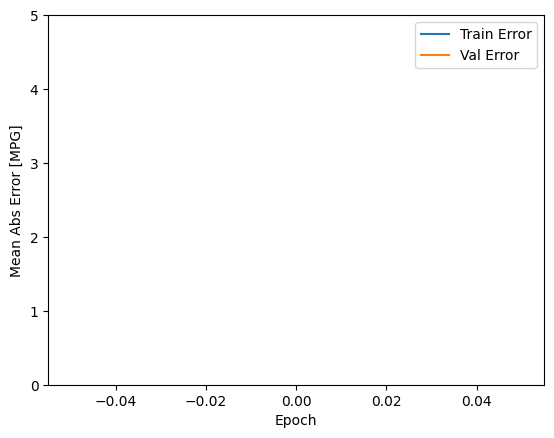

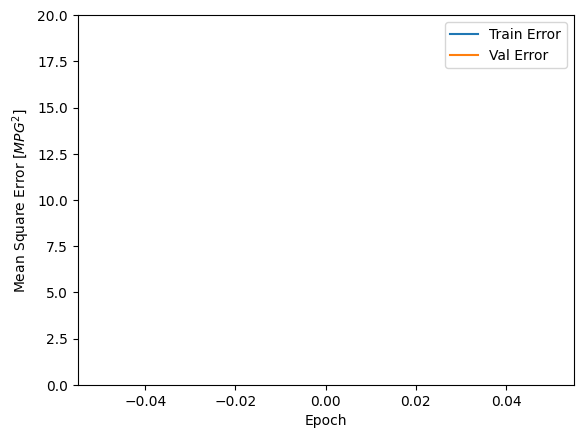

In [29]:
def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch

  plt.figure()
  plt.xlabel('Epoch')
  plt.ylabel('Mean Abs Error [MPG]')
  plt.plot(hist['epoch'], hist['mean_absolute_error'],
           label='Train Error')
  plt.plot(hist['epoch'], hist['val_mean_absolute_error'],
           label = 'Val Error')
  plt.ylim([0,5])
  plt.legend()

  plt.figure()
  plt.xlabel('Epoch')
  plt.ylabel('Mean Square Error [$MPG^2$]')
  plt.plot(hist['epoch'], hist['mean_squared_error'],
           label='Train Error')
  plt.plot(hist['epoch'], hist['val_mean_squared_error'],
           label = 'Val Error')
  plt.ylim([0,20])
  plt.legend()
  plt.show()

plot_history(history)


...........

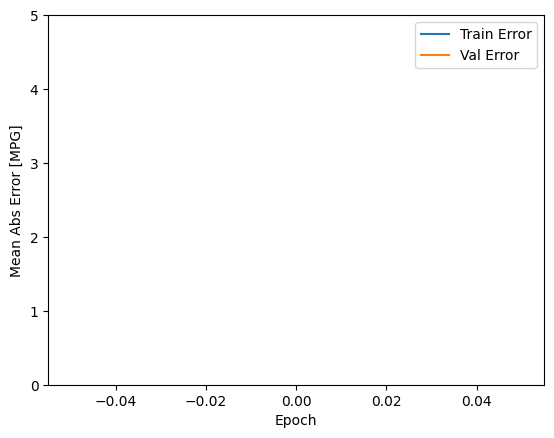

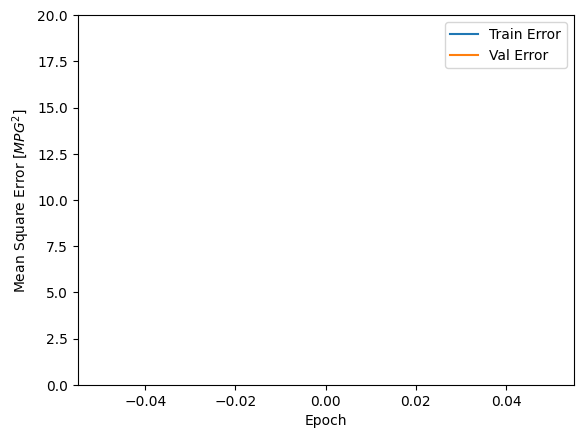

In [31]:
model = build_model()

# The patience parameter is the amount of epochs to check for improvement
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)

history = model.fit(normed_train_data, train_labels, epochs=EPOCHS,
                    validation_split = 0.2, verbose=0, callbacks=[early_stop, PrintDot()])

plot_history(history)

In [32]:
loss, mae, mse = model.evaluate(normed_test_data, test_labels, verbose=0)
print("Testing set Mean Abs Error: {:5.2f} MPG".format(mae))

Testing set Mean Abs Error:   nan MPG


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


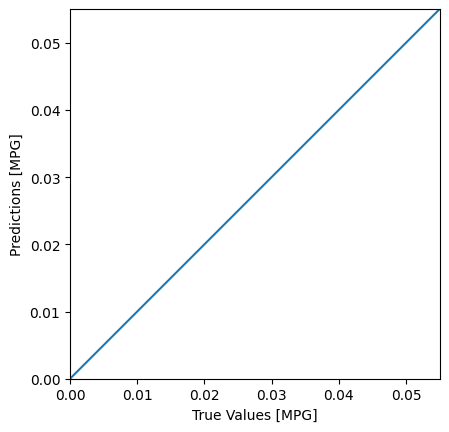

In [33]:
test_predictions = model.predict(normed_test_data).flatten()

plt.scatter(test_labels, test_predictions)
plt.xlabel('True Values [MPG]')
plt.ylabel('Predictions [MPG]')
plt.axis('equal')
plt.axis('square')
plt.xlim([0,plt.xlim()[1]])
plt.ylim([0,plt.ylim()[1]])
_ = plt.plot([-100, 100], [-100, 100])